# 3. Variant effects

Language models assign probabilities to sequences, so they can score how "surprising" a
mutation is without any training on variant data (zero-shot). This notebook scores the
sickle-cell variant in HBB with every model, predicts a masked base with NTv3, and scans
every possible substitution in the first codons.

> These scores illustrate the API. A zero-shot language-model score is **not** a clinical
> prediction.

> Run the series in order the first time: notebook 01 explains the setup. Every notebook
> starts by connecting to the services through `tutorial_utils.py` next to it; a service
> that isn't running is skipped.

In [1]:
from tutorial_utils import HBB, SNP_ALT, SNP_POS, connect, default_checkpoints, show_table

clients = connect()
defaults = default_checkpoints(clients)
print(
    "HBB codons 1-7:",
    " ".join(HBB[i : i + 3] for i in range(0, 21, 3)),
    f"| variant: position {SNP_POS} {HBB[SNP_POS]}>{SNP_ALT}",
)

server http://localhost | token set: True | up: ntv3, ntv2, dnabert2, hyenadna, evo2, generator, genalm, grover


HBB codons 1-7: ATG GTG CAC CTG ACT CCT GAG | variant: position 19 A>T


## `score_snp` with every model

`score_snp(sequence, alternative_allele, position)` returns `score_delta`: negative means the
model finds the mutated sequence less likely than the reference. How it is computed is in
the `method` field:

- `single_position_masked_lm_log_prob` (NTv3): mask the position and compare the
  log-probabilities of the alternative and the reference base;
- `whole_sequence_log_prob_delta` (all others): log-likelihood of the mutated sequence minus
  that of the reference. Masked models (NTv2, DNABERT-2, GENA-LM, GROVER) use a
  pseudo-log-likelihood (mask each token in turn); causal models (HyenaDNA, Evo 2,
  GENERator) use the exact log-likelihood.

Different methods and models give numbers on different scales: compare variants **within**
one model, not across models.

In [2]:
rows = []
for name, c in clients.items():
    out = c.score_snp(HBB, SNP_ALT, checkpoint=defaults[name], position=SNP_POS)
    rows.append(
        {
            "service": name,
            "checkpoint": defaults[name],
            "score_delta": out["score_delta"],
            "method": out["method"],
        }
    )
show_table(rows)

service    checkpoint         score_delta  method                            
---------  -----------------  -----------  ----------------------------------
ntv3       100m-pre           -0.6054      single_position_masked_lm_log_prob
ntv2       500m               1.6569       whole_sequence_log_prob_delta     
dnabert2   117m               0.1809       whole_sequence_log_prob_delta     
hyenadna   medium-160k        -0.0812      whole_sequence_log_prob_delta     
evo2       7b                 -18.4634     whole_sequence_log_prob_delta     
generator  v2-eukaryote-1.2b  -13.4788     whole_sequence_log_prob_delta     
genalm     bert-large-t2t     -0.3292      whole_sequence_log_prob_delta     
grover     grover             3.8444       whole_sequence_log_prob_delta     


## Masked prediction (NTv3)

With one token per base, NTv3 can predict what belongs at a masked position. Mark positions
with `N`; the tool returns the top-k bases with probabilities for each.

In [3]:
if "ntv3" in clients:
    masked = HBB[:SNP_POS] + "N" + HBB[SNP_POS + 1 :]
    pred = clients["ntv3"].predict_masked_positions(masked, top_k=4)
    for p in pred["predictions"]:
        probs = ", ".join(f"{q['nucleotide']}={q['probability']:.2f}" for q in p["predictions"])
        print(f"position {p['position']} (true base {HBB[p['position']]}): {probs}")

position 19 (true base A): A=0.49, T=0.27, G=0.16, C=0.08


## A mutation scan

Scoring every possible substitution along a sequence (in-silico mutagenesis) shows where a
model expects change to hurt. In a coding sequence, the third base of a codon is often
synonymous (the amino acid doesn't change), so a model that has learned protein-coding
constraints should penalise mutations at codon positions 1 and 2 more than at position 3.

We scan the first 10 codons with one causal model (Evo 2 if it is running): 30 positions x 3
alternative bases = 90 `score_snp` calls.

In [4]:
scanner = next((s for s in ["evo2", "generator", "hyenadna"] if s in clients), None)
c = clients[scanner]
deltas = {}  # (position, alt) -> score_delta
for pos in range(30):
    for alt in "ACGT":
        if alt != HBB[pos]:
            deltas[pos, alt] = c.score_snp(HBB, alt, checkpoint=defaults[scanner], position=pos)[
                "score_delta"
            ]

for codon_pos in (1, 2, 3):
    values = [d for (pos, _), d in deltas.items() if pos % 3 == codon_pos - 1]
    print(
        f"{scanner}: codon position {codon_pos}: mean score_delta {sum(values) / len(values):+.2f}"
    )

evo2: codon position 1: mean score_delta -4.79
evo2: codon position 2: mean score_delta -8.71
evo2: codon position 3: mean score_delta -4.08


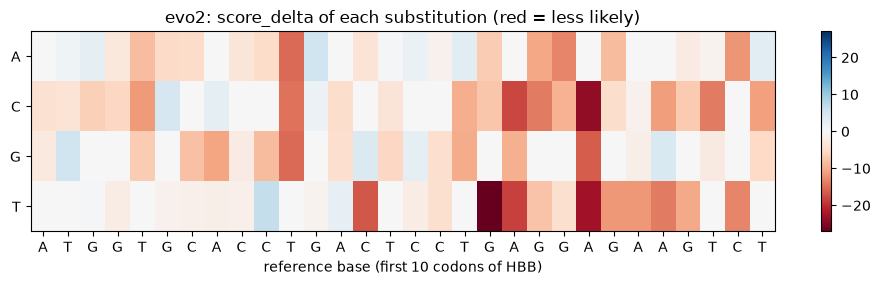

In [5]:
try:
    import matplotlib.pyplot as plt

    grid = [[deltas.get((pos, alt), 0.0) for pos in range(30)] for alt in "ACGT"]
    fig, ax = plt.subplots(figsize=(12, 2.6))
    im = ax.imshow(
        grid,
        cmap="RdBu",
        vmin=-max(map(abs, deltas.values())),
        vmax=max(map(abs, deltas.values())),
        aspect="auto",
    )
    ax.set_yticks(range(4), list("ACGT"))
    ax.set_xticks(range(30), list(HBB[:30]))
    ax.set_xlabel("reference base (first 10 codons of HBB)")
    ax.set_title(f"{scanner}: score_delta of each substitution (red = less likely)")
    fig.colorbar(im, ax=ax)
    plt.show()
except ImportError:
    print("(matplotlib is not installed)")

Cells with the reference base are 0. Columns where every substitution is strongly negative
mark positions the model considers constrained, such as the start codon `ATG`.

**Next:** [4. Generation](04_generation.ipynb)